In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Box plots of intrinsic dimension 

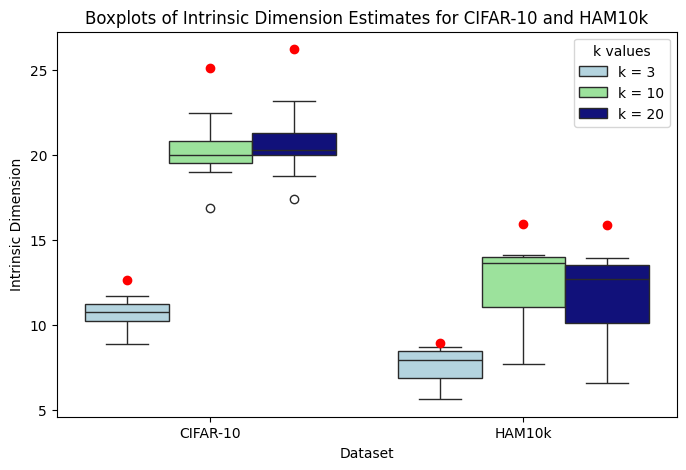

In [2]:
# Define k values
ks = [3, 10, 20]  

# Dummy intrinsic dimension data (replace with actual computed values)
cifar10_dims = {3: [8.87, 10.12, 11, 10.71, 10.38, 11.4, 10.03, 11.29, 10.76, 11.71], 
                10: [16.84, 19.44, 20.06, 19.76, 19.87, 20.84, 20.87, 20.80, 18.95, 22.43],
                20: [17.37, 20.09, 20.22, 19.97, 20.30, 20.95, 21.75, 21.38, 18.76, 23.14]}

ham10k_dims = {3: [8.70, 8.48, 8.39, 5.88, 7.81, 7.91, 5.61],
                10: [13.63, 13.55, 14.07, 8.5, 13.93, 14.03, 7.66],
                20: [12.7, 12.53, 13.57, 7.61, 13.42, 13.94, 6.59]}

# Full dataset estimates (replace with actual values)
cifar10_full = {3: [12.63], 10: [25.07], 20: [26.2]}
ham10k_full = {3: [8.92], 10: [15.89], 20: [15.86]}

# Create a DataFrame
df_list = []
for k in ks:
    df_list.append(pd.DataFrame({
        "Intrinsic Dimension": np.concatenate([cifar10_dims[k], ham10k_dims[k]]),
        "Dataset": ["CIFAR-10"] * len(cifar10_dims[k]) + ["HAM10k"] * len(ham10k_dims[k]),
        "k": [f"k = {k}"] * (len(cifar10_dims[k]) + len(ham10k_dims[k]))
    }))
df = pd.concat(df_list)

# Create the box plot
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x="Dataset", y="Intrinsic Dimension", hue="k", data=df, palette=["lightblue", "lightgreen", "darkblue"])

# Get base x-tick positions (centers of CIFAR-10 and HAM10k)
x_ticks = np.array(ax.get_xticks())  

# Compute offsets for each k using Seaborn's internal spacing
num_k = len(ks)
box_group_width = 0.8  # Total width of grouped boxes (Seaborn default)
spacing = np.linspace(-box_group_width / 3, box_group_width / 3, num_k)  # Compute exact offsets

# Plot the red dots at the correct locations
for i, k in enumerate(ks):
    plt.scatter(
        x_ticks + spacing[i],  # Shift red dots precisely to center of each k box
        [cifar10_full[k], ham10k_full[k]],  
        color="red",
        zorder=3,
        label=None
    )

# Labels and legend
plt.ylabel("Intrinsic Dimension")
plt.legend(title="k values")
plt.title("Boxplots of Intrinsic Dimension Estimates for CIFAR-10 and HAM10k")

plt.show()


## Correlation between class intrinsic dimension and test accuracy

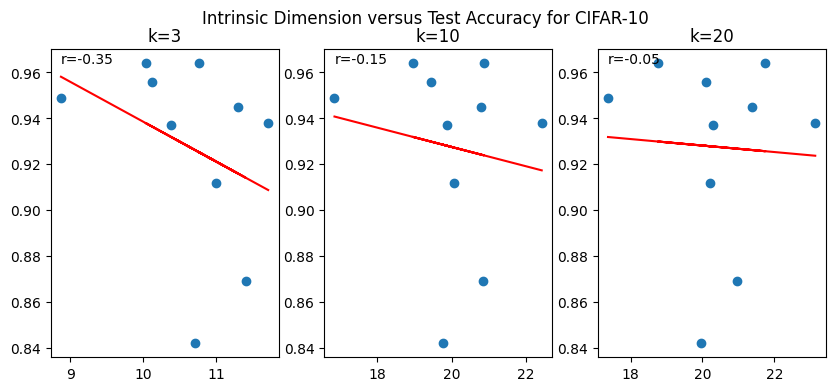

In [3]:
cifar10_accs = [0.949, 0.956, 0.912, 0.842, 0.937, 0.869, 0.964, 0.945, 0.964, 0.938]

fig, ax = plt.subplots(1, 3, figsize=(10,4))
for idx, k in enumerate(ks):
    x = cifar10_dims[k]
    y = cifar10_accs
    ax[idx].scatter(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    regression_line = slope * np.array(x) + intercept
    correlation_coefficient = np.corrcoef(x, y)[0, 1]
    ax[idx].text(min(x), max(y), f"r={correlation_coefficient:.2f}", fontsize=10, color="black")
    ax[idx].plot(x, regression_line, color="red")
    ax[idx].set_title(f"k={k}")
fig.suptitle("Intrinsic Dimension versus Test Accuracy for CIFAR-10")
plt.show()

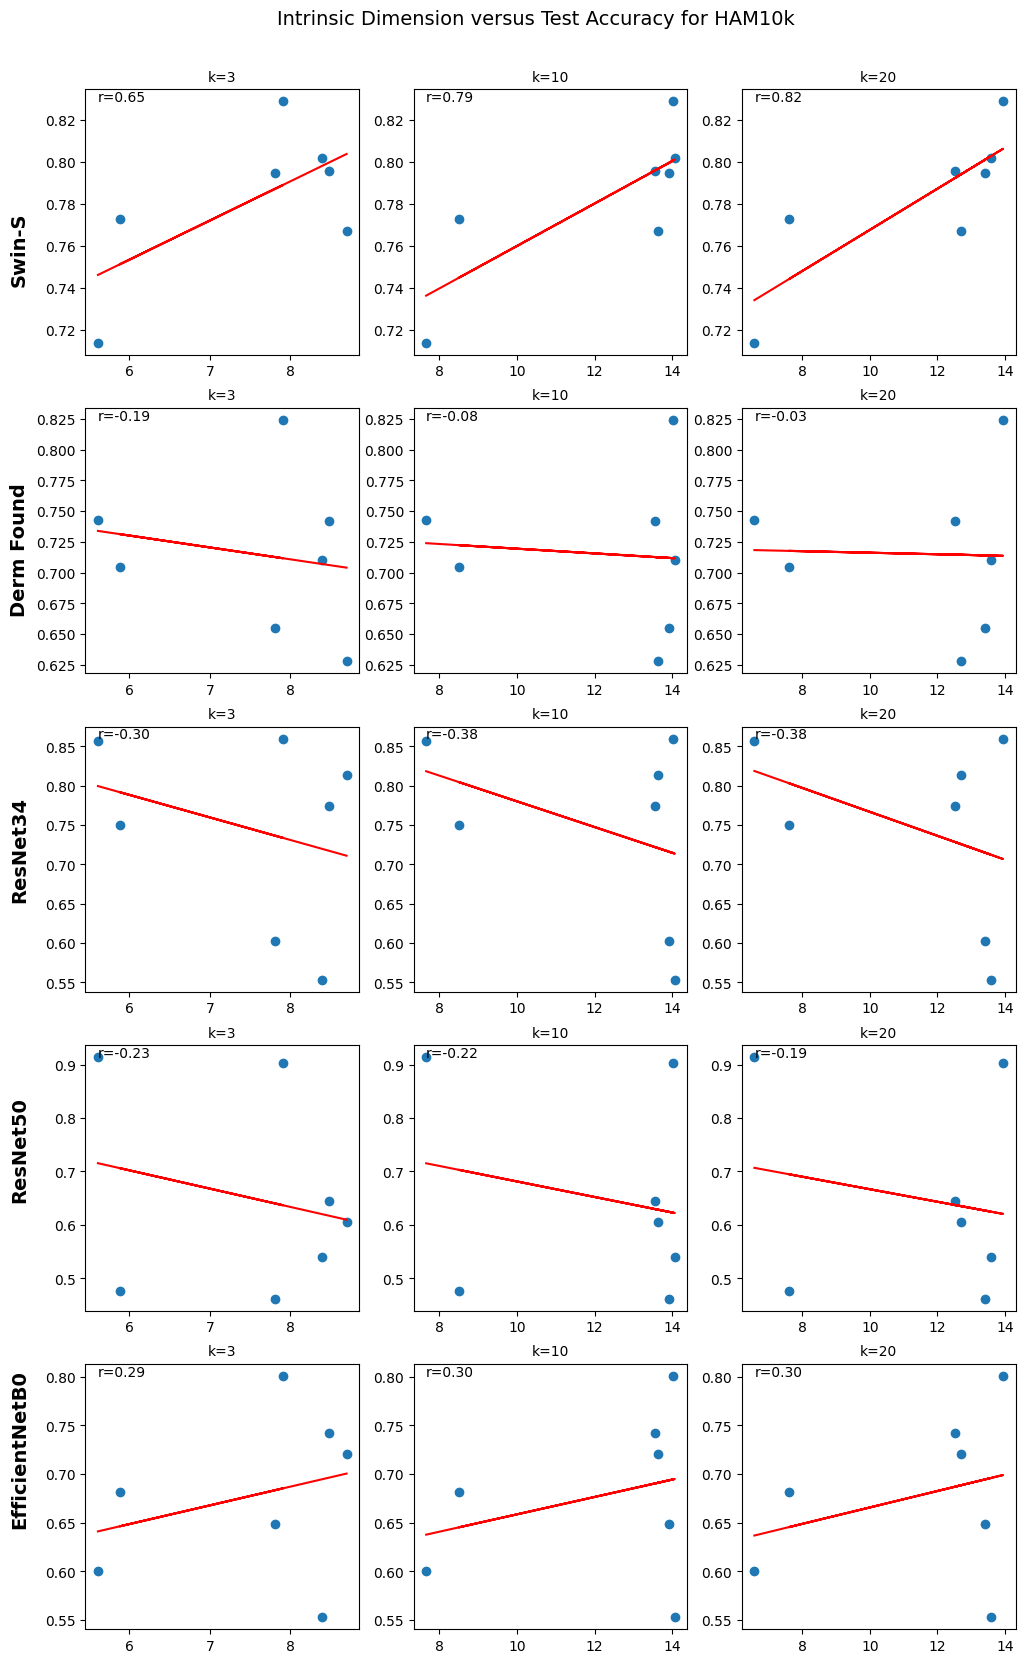

In [37]:
ham10k_accs = [[0.767, 0.796, 0.802, 0.773, 0.795, 0.829, 0.714],
                [0.628, 0.742, 0.710, 0.705, 0.655, 0.824, 0.743],
                [0.814, 0.774, 0.553, 0.750, 0.602, 0.860, 0.857],
                [0.605, 0.645, 0.539, 0.477, 0.462, 0.904, 0.914],
                [0.721, 0.742, 0.553, 0.682, 0.649, 0.801, 0.600]
            ]
row_titles = ["Swin-S", "Derm Found", "ResNet34", "ResNet50", "EfficientNetB0"]
title_locations = np.linspace(0.8,0.2,5)

fig, ax = plt.subplots(5, 3, figsize=(12,20))
for i in range(len(ks) * len(ham10k_accs)):
    row = i // len(ks)
    col = i % len(ks)
    x = ham10k_dims[ks[col]]
    y = ham10k_accs[row]
    ax[row, col].scatter(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    regression_line = slope * np.array(x) + intercept
    correlation_coefficient = np.corrcoef(x, y)[0, 1]
    ax[row, col].text(min(x), max(y), f"r={correlation_coefficient:.2f}", fontsize=10, color="black")
    ax[row, col].plot(x, regression_line, color="red")
    ax[row, col].set_title(f"k={ks[col]}", fontsize=10)

    if (i+1) % 3 == 0:
        fig.text(
            x=0.07,  # Adjust as needed
            y=title_locations[row],  # Center the title in the row
            s=row_titles[row],
            va="center",
            ha="center",
            fontsize=14,
            fontweight="bold",
            rotation=90  # Rotate to align with rows
        )

fig.suptitle("Intrinsic Dimension versus Test Accuracy for HAM10k", fontsize=14, y=0.92)
plt.show()


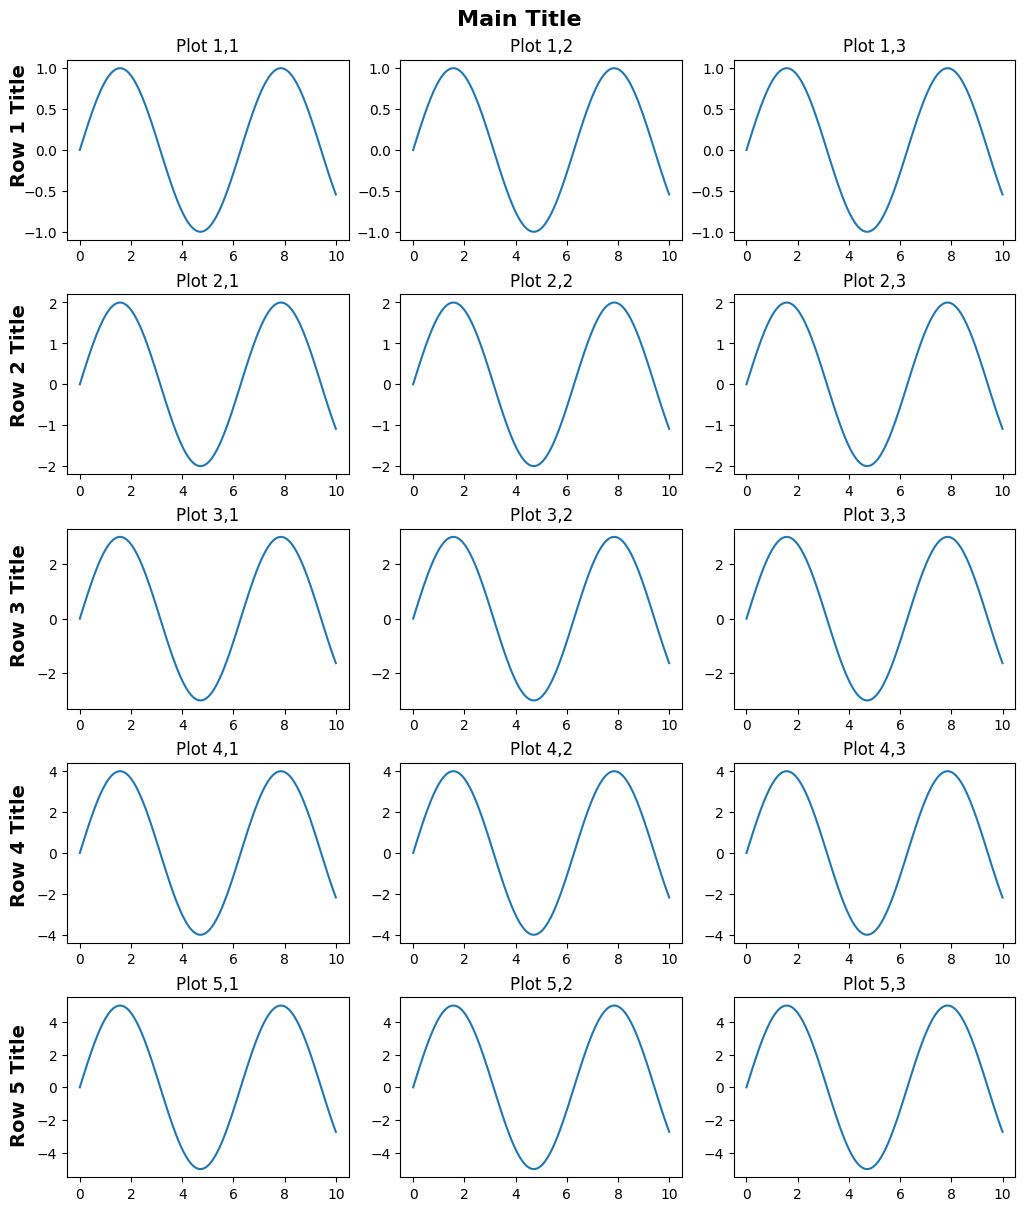

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Create 5x3 subplots
fig, axes = plt.subplots(5, 3, figsize=(10, 12), constrained_layout=True)

# Row titles
row_titles = ["Row 1 Title", "Row 2 Title", "Row 3 Title", "Row 4 Title", "Row 5 Title"]

# Loop through subplots
for i in range(5):
    for j in range(3):
        axes[i, j].plot(x, y * (i + 1))  # Example plot
        axes[i, j].set_title(f"Plot {i+1},{j+1}")  # Individual subplot titles

    # Add row title at the left side
    fig.text(
        x=0,  # Adjust as needed
        y=1 - (i + 0.5) / 5,  # Center the title in the row
        s=row_titles[i],
        va="center",
        ha="center",
        fontsize=14,
        fontweight="bold",
        rotation=90  # Rotate to align with rows
    )

# Add a suptitle for the entire figure
fig.suptitle("Main Title", fontsize=16, fontweight="bold")

plt.show()
